In [5]:
import random
import json

# This section generates a list of random coordinates.
# The initial format is a list of dictionaries, which will be
# converted to a list of tuples (X, Y) later for the KD-tree.

lista_coordenadas = []

# Generate 10,000 data points with 'X' and 'Y' coordinates.
# Each coordinate is a random integer between 0 and 10000.
for i in range(10000):
    x = random.randint(0, 10000)
    y = random.randint(0, 10000)
    entrega = {
        "X": x,
        "Y": y
    }
    lista_coordenadas.append(entrega)

# Print a preview of the first few generated coordinates
# to demonstrate the structure of 'lista_coordenadas'.
print("coordenadas = [")
for i in range(3):
    e = lista_coordenadas[i]
    print(f'    {{"X": {e["X"]}, "Y": {e["Y"]}}},')
print("    # ... y así hasta 10,000")
print("]")

coordenadas = [
    {"X": 9925, "Y": 5134},
    {"X": 6514, "Y": 8296},
    {"X": 1350, "Y": 6484},
    # ... y así hasta 10,000
]


###***construccion de el arbol***

In [6]:
import math
import statistics

''' IMPORTANTE
se calcula la media asumiendo que los datos estan distribuidos de manera homogenea
se ordena los datos respecto al eje y se divide a la mitad para encontrar la mediana
'''

# Clase para representar un nodo en el KD-tree.
# Cada nodo almacena una coordenada (punto), sus hijos izquierdo y derecho,
# y el eje de división que se usó para crearlo.
class nodocoordenada:
    def __init__(self, coordenada, eje):
        self.punto = coordenada      # La coordenada (punto) almacenada en este nodo.
        self.izquierdo = None      # Referencia al hijo izquierdo (subárbol).
        self.derecho = None       # Referencia al hijo derecho (subárbol).
        self.eje = eje           # Eje de división (0 para X, 1 para Y, etc.).

# Clase principal del KD-tree.
# Permite construir el árbol y realizar búsquedas de vecinos cercanos o dentro de un radio.
class Kdtree:
    def __init__(self, coordenadas, k):
        # 'coordenadas' es una lista de puntos (tuplas).
        # 'k' es la dimensión de los puntos (ej. 2 para (X,Y)).
        self.raiz = self.construir(coordenadas, k, 0) # Construye el árbol a partir de las coordenadas.
        self.dimension = k                            # Almacena la dimensión del espacio.

    # Método recursivo para construir el KD-tree.
    # Divide los puntos en cada nivel basándose en un eje alternante.
    def construir(self, coordenada, k, nivel=0):
        # Caso base: si no hay coordenadas, devuelve None.
        if len(coordenada) == 0:
            return None

        # Determina el eje de división para el nivel actual (X, Y, X, Y, ...).
        eje = nivel % k

        # Ordena las coordenadas basándose en el valor del eje actual.
        coordenada.sort(key=lambda p: p[eje])

        # Encuentra el índice de la mediana para dividir el conjunto de puntos.
        mediana_idx = len(coordenada) // 2

        # El punto medio será el punto de división para el nodo actual.
        punto_medio = coordenada[mediana_idx]

        # Divide las coordenadas en dos sublistas: izquierda y derecha.
        izquierdo = coordenada[:mediana_idx]
        derecho = coordenada[mediana_idx + 1:]

        # Crea un nuevo nodo con el punto medio y el eje de división.
        nodo = nodocoordenada(punto_medio, eje)

        # Construye recursivamente los subárboles izquierdo y derecho.
        nodo.izquierdo = self.construir(izquierdo, k, nivel + 1)
        nodo.derecho = self.construir(derecho, k, nivel + 1)

        return nodo # Devuelve el nodo raíz del subárbol actual.

    # Calcula la distancia euclidiana entre dos puntos.
    def distancia(self, punto1, punto2):
        sum_sq = 0
        for i in range(len(punto1)):
            sum_sq += (punto1[i] - punto2[i]) ** 2
        return math.sqrt(sum_sq)

    # Busca el vecino más cercano a un punto objetivo en el KD-tree.
    def buscar_cercano(self, nodo, punto, mejor=None):
        # Caso base: si el nodo es None, devuelve el mejor encontrado hasta ahora.
        if nodo is None:
            return mejor

        # Si no hay un 'mejor' punto o el punto actual es más cercano,
        # actualiza 'mejor'.
        if (mejor is None) or self.distancia(punto, nodo.punto) < self.distancia(punto, mejor):
            mejor = nodo.punto

        eje = nodo.eje # Eje de división del nodo actual.

        # Decide qué rama explorar primero (la que contiene el punto objetivo).
        if punto[eje] < nodo.punto[eje]:
            siguiente = nodo.izquierdo # Rama principal
            opuesto = nodo.derecho    # Rama opuesta
        else:
            siguiente = nodo.derecho  # Rama principal
            opuesto = nodo.izquierdo # Rama opuesta

        # Explora la rama principal primero.
        mejor = self.buscar_cercano(siguiente, punto, mejor)

        # Si la distancia del punto objetivo al plano de división del nodo
        # es menor que la distancia al 'mejor' punto encontrado hasta ahora,
        # vale la pena explorar la rama opuesta.
        if abs(punto[eje] - nodo.punto[eje]) < self.distancia(punto, mejor):
            mejor = self.buscar_cercano(opuesto, punto, mejor)

        return mejor # Devuelve el punto más cercano encontrado.

    # Busca todos los puntos dentro de un radio dado alrededor de un punto objetivo.
    def buscar_en_radio(self, nodo, punto, radio, encontrados=None):
        # Inicializa la lista de encontrados si es la primera llamada.
        if encontrados is None:
            encontrados = []

        # Caso base: si el nodo es None, devuelve los puntos encontrados.
        if nodo is None:
            return encontrados

        # Verifica si el punto del nodo actual está dentro del radio.
        if self.distancia(punto, nodo.punto) <= radio:
            encontrados.append(nodo.punto)

        eje = nodo.eje # Eje de división del nodo actual.

        # Decide qué ramas explorar basándose en la posición del punto objetivo
        # respecto al plano de división.
        if punto[eje] < nodo.punto[eje]:
            siguiente = nodo.izquierdo # Rama principal
            opuesto = nodo.derecho    # Rama opuesta
        else:
            siguiente = nodo.derecho  # Rama principal
            opuesto = nodo.izquierdo # Rama opuesta

        # Explora la rama principal recursivamente.
        encontrados = self.buscar_en_radio(siguiente, punto, radio, encontrados)

        # Si el radio cruza el plano de división, es posible que haya puntos
        # en la rama opuesta que estén dentro del radio. Explora la rama opuesta.
        if abs(punto[eje] - nodo.punto[eje]) <= radio:
            encontrados = self.buscar_en_radio(opuesto, punto, radio, encontrados)

        return encontrados # Devuelve la lista de puntos dentro del radio.

###***codigo para graficar el arbol (hecho con vcode)***

In [7]:
def graficar_kdtree(nodo, xmin, xmax, ymin, ymax, ax,
                    profundidad=0, max_profundidad=10):
    if nodo is None or profundidad > max_profundidad:
        return

    x, y = nodo.punto

    if nodo.eje == 0:
        # línea vertical
        ax.plot([x, x], [ymin, ymax], linewidth=0.8)

        graficar_kdtree(nodo.izquierdo, xmin, x, ymin, ymax, ax,
                        profundidad+1, max_profundidad)
        graficar_kdtree(nodo.derecho, x, xmax, ymin, ymax, ax,
                        profundidad+1, max_profundidad)

    else:
        # línea horizontal
        ax.plot([xmin, xmax], [y, y], linewidth=0.8)

        graficar_kdtree(nodo.izquierdo, xmin, xmax, ymin, y, ax,
                        profundidad+1, max_profundidad)
        graficar_kdtree(nodo.derecho, xmin, xmax, y, ymax, ax,
                        profundidad+1, max_profundidad)

In [8]:
def ajustar_zoom(ax, puntos, objetivo=None, radio=None, margen=1.2):
    if objetivo is not None:
        if radio is not None:
            # Zoom centrado en el objetivo
            xmin = objetivo[0] - radio * margen
            xmax = objetivo[0] + radio * margen
            ymin = objetivo[1] - radio * margen
            ymax = objetivo[1] + radio * margen
        else:
            # Zoom alrededor del objetivo sin radio
            xmin = objetivo[0] - 10
            xmax = objetivo[0] + 10
            ymin = objetivo[1] - 10
            ymax = objetivo[1] + 10
    else:
        # fallback si no hay objetivo
        xs = [p[0] for p in puntos]
        ys = [p[1] for p in puntos]

        xmin, xmax = min(xs), max(xs)
        ymin, ymax = min(ys), max(ys)

    ax.set_xlim(xmin, xmax)
    ax.set_ylim(ymin, ymax)

In [9]:
import matplotlib.pyplot as plt

def graficar_busqueda(puntos, objetivo, radio, vecinos, vecino_cercano, arbol=None):
    plt.style.use('fast')  # mejora rendimiento

    fig, ax = plt.subplots()

    # --- TODOS LOS PUNTOS (rápido)
    xs = [p[0] for p in puntos]
    ys = [p[1] for p in puntos]
    ax.scatter(xs, ys, s=10)

    # --- VECINOS (destacados)
    if vecinos:
        vx = [p[0] for p in vecinos]
        vy = [p[1] for p in vecinos]
        ax.scatter(vx, vy, s=30)

    # --- VECINO MÁS CERCANO
    if vecino_cercano:
        ax.scatter(vecino_cercano[0], vecino_cercano[1], s=80, marker='x')

    # --- OBJETIVO
    ax.scatter(objetivo[0], objetivo[1], s=80, marker='x')

    # --- RADIO
    circulo = plt.Circle(objetivo, radio, fill=False, linewidth=1.5)
    ax.add_patch(circulo)

    # --- KD TREE (opcional)
    if arbol:
        graficar_kdtree(arbol.raiz,
                        xmin=min(xs), xmax=max(xs),
                        ymin=min(ys), ymax=max(ys),
                        ax=ax,
                        max_profundidad=10)

    # --- ZOOM AUTOMÁTICO
    ajustar_zoom(ax, puntos, objetivo, radio)

    ax.set_aspect('equal')
    plt.grid()
    plt.show()

###***codigo para ejecutar el arbol y mostrar la grafica***

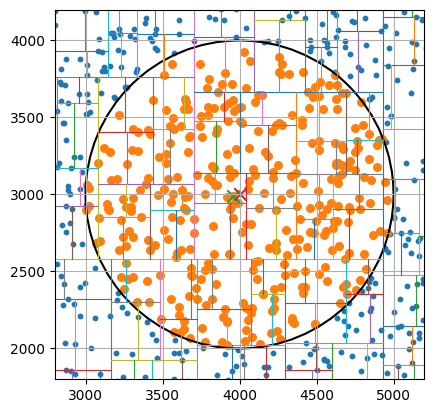

In [10]:
lista_coordenadas_tuples = [(coord["X"], coord["Y"]) for coord in lista_coordenadas]
objetivo = (4000,3000)
radio = 1000
arbol = Kdtree(lista_coordenadas_tuples, 2)
cercano=arbol.buscar_cercano(arbol.raiz,objetivo)
vecinos=arbol.buscar_en_radio(arbol.raiz,objetivo,radio)
graficar_busqueda(lista_coordenadas_tuples, objetivo, radio, vecinos, cercano, arbol)

###***codigo para las pruebas de Rendimiento***


In [4]:
def distancia(punto1, punto2):
    sum = 0
    for i in range(len(punto1)):
        sum += (punto1[i] - punto2[i]) ** 2
    sum = math.sqrt(sum)
    return sum
def fuerza_bruta(puntos, objetivo):
    mejor = None
    mejor_dist= float('inf')

    for p in puntos:
        d = distancia(p, objetivo)
        if d < mejor_dist:
            mejor = p
            mejor_dist = d

    return mejor

def radio_fb(puntos, obj, radio):
    vecinos = []
    for p in puntos:
        if distancia(p, obj) <= radio:
            vecinos.append(p)
    return vecinos

In [12]:
import time
import random
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

def generar_puntos(n):
    return [(random.randint(0, 10000), random.randint(0,10000))for _ in range(n)]

def experimento(tamaño , obj):
    resultados = []
    objetivo = obj
    for n in tamaño:
        puntos = generar_puntos(n)
        promedio_tiempo_fb = 0
        promedio_tiempo_ca = 0
        promedio_tiempo_ab = 0
        for _ in range(50):
            #fuerza bruta
            t0 = time.time()
            fuerza_bruta(puntos, objetivo)
            t1 = time.time()

            tiempo_fb= t1 - t0
            promedio_tiempo_fb += tiempo_fb
        promedio_tiempo_fb= promedio_tiempo_fb/50

        for _ in range(50):
            #arbol-creacion
            t0 = time.time()
            arbol = Kdtree(puntos, 2)
            t1 = time.time()

            tiempo_ca= t1 - t0
            promedio_tiempo_ca += tiempo_ca
        promedio_tiempo_ca= promedio_tiempo_ca/50

        for _ in range(50):
            #arbol-busqueda
            t0 = time.time()
            arbol.buscar_cercano(arbol.raiz,objetivo)
            t1 = time.time()

            tiempo_ab= t1 - t0
            promedio_tiempo_ab += tiempo_ab
        promedio_tiempo_ab= promedio_tiempo_ab/50

        resultados.append((n, promedio_tiempo_fb, promedio_tiempo_ca, promedio_tiempo_ab , promedio_tiempo_ca + promedio_tiempo_ab))
    return resultados

def experimento_radio(tamaño , obj, radios):
    resultados = []
    objetivo = obj
    for n in tamaño:
        puntos = generar_puntos(n)

        for radio in radios:
            promedio_tiempo_fb = 0
            promedio_tiempo_ca = 0
            promedio_tiempo_ab = 0


            for _ in range(50):
                #arbol-creacion
                t0 = time.time()
                arbol = Kdtree(puntos, 2)
                t1 = time.time()

                tiempo_ca= t1 - t0
                promedio_tiempo_ca += tiempo_ca
            promedio_tiempo_ca= promedio_tiempo_ca/50

            for _ in range(50):
                #fuerza bruta
                t0 = time.time()
                radio_fb(puntos, objetivo, radio)
                t1 = time.time()

                tiempo_fb= t1 - t0
                promedio_tiempo_fb += tiempo_fb
            promedio_tiempo_fb= promedio_tiempo_fb/50


            for _ in range(50):
                #arbol-busqueda
                t0 = time.time()
                arbol.buscar_en_radio(arbol.raiz,objetivo,radio)
                t1 = time.time()

                tiempo_ab= t1 - t0
                promedio_tiempo_ab += tiempo_ab
            promedio_tiempo_ab= promedio_tiempo_ab/50

            resultados.append((n,radio, promedio_tiempo_fb, promedio_tiempo_ca, promedio_tiempo_ab , promedio_tiempo_ca + promedio_tiempo_ab))
    return resultados



### **prueba de rendimiento para encontrar al vecino mas cercano y grafica**

Para evaluar el desempeño del árbol k-d en la búsqueda del vecino más cercano, se diseñó un experimento comparando este método con el enfoque de fuerza bruta.

Se generaron conjuntos de datos de distintos tamaños (n = 100, 2000, 4000, 6000, 8000, 10000), con puntos distribuidos aleatoriamente en el plano. Para cada conjunto, se definió un punto objetivo y se realizó la búsqueda del punto más cercano.

El experimento midió tres componentes principales en el caso del árbol k-d:
- el tiempo de construcción del árbol,
- el tiempo de búsqueda del vecino más cercano,
- y el tiempo total (suma de ambos).

Por otro lado, para el método de fuerza bruta, se midió el tiempo de búsqueda comparando el punto objetivo con todos los puntos del conjunto.

##**Resultados observados**

Los resultados muestran que:

- El tiempo de búsqueda del árbol k-d es extremadamente bajo (del orden de 10^-5 segundos), siendo prácticamente constante incluso al aumentar el tamaño de los datos.
- El tiempo de construcción del árbol crece con el tamaño del conjunto, alcanzando valores cercanos a 0.05 segundos para 10,000 puntos.
- El tiempo total del árbol k-d está dominado por el costo de construcción, lo que lo hace significativamente más lento que la fuerza bruta en todos los tamaños evaluados.

En contraste, el método de fuerza bruta presenta un crecimiento progresivo en el tiempo de ejecución, pasando de valores muy bajos en conjuntos pequeños (~10^-4 segundos) hasta aproximadamente 0.005 segundos en 10,000 puntos.

## **Conclusión**

A partir de los resultados, se concluye que:

Para los tamaños de datos analizados, el método de fuerza bruta resulta más eficiente que el árbol k-d cuando se realiza una única búsqueda del vecino más cercano.

Esto se debe a que el costo de construcción del árbol k-d es considerablemente mayor que el tiempo requerido por la fuerza bruta para recorrer todos los puntos.

Sin embargo, también se observa que:

El tiempo de búsqueda del árbol k-d es significativamente menor y prácticamente constante, lo que lo convierte en una alternativa mucho más eficiente cuando se requieren múltiples consultas sobre el mismo conjunto de datos.

En estos casos, el costo de construcción del árbol se amortiza, y el rendimiento global del árbol k-d supera ampliamente al método de fuerza bruta.

(100, 8.621692657470703e-05, 0.0001529884338378906, 2.643585205078125e-05, 0.00017942428588867186)
(2000, 0.0013210248947143554, 0.005516796112060547, 3.520965576171875e-05, 0.0055520057678222655)
(4000, 0.0020438766479492186, 0.015304522514343262, 0.00012154579162597657, 0.015426068305969239)
(6000, 0.0032790231704711913, 0.02488041400909424, 6.229877471923828e-05, 0.024942712783813478)
(8000, 0.004286684989929199, 0.03596628189086914, 5.358219146728516e-05, 0.03601986408233642)
(10000, 0.005534868240356445, 0.04720828533172607, 2.8471946716308594e-05, 0.047236757278442384)


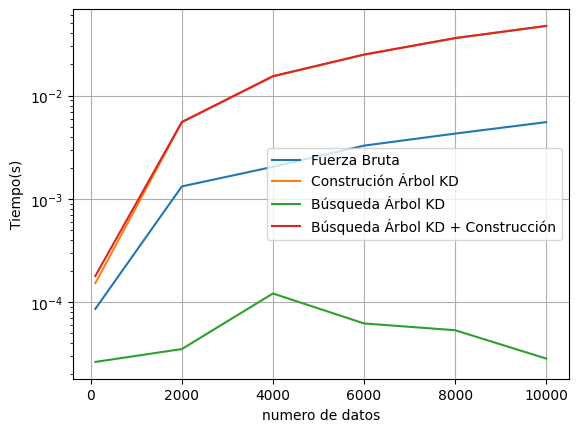

/tmp/ipykernel_15114/2777143226.py:53: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


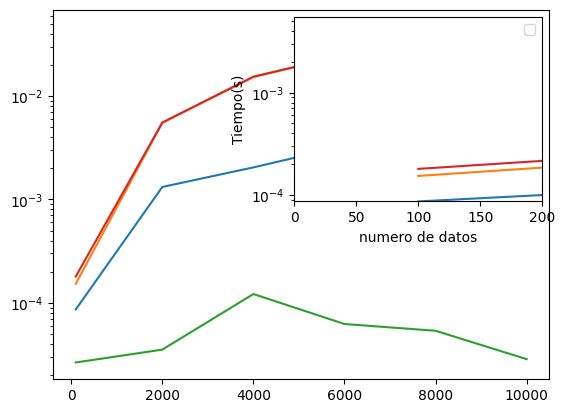

In [13]:
tamaño = [100,2000,4000,6000,8000,10000]
exp = experimento(tamaño,(5000,5000))
n = []
fb=[]
ac=[]
ab=[]
ca = []
for r in exp:
    n.append(r[0])
    fb.append(r[1])
    ac.append(r[2])
    ab.append(r[3])
    ca.append(r[4])
    print(r)

plt.plot(n, fb, label='Fuerza Bruta')
plt.plot(n, ac, label='Construción Árbol KD')
plt.plot(n, ab, label='Búsqueda Árbol KD')
plt.plot(n, ca, label='Búsqueda Árbol KD + Construcción')

plt.xlabel('numero de datos')
plt.ylabel('Tiempo(s)')
plt.legend()
plt.yscale("log")
plt.grid()
plt.show()

fig, ax = plt.subplots()
ax.plot(n, fb, label='Fuerza Bruta')
ax.plot(n, ac, label='Construción Árbol KD')
ax.plot(n, ab, label='Búsqueda Árbol KD')
ax.plot(n, ca, label='Búsqueda Árbol KD + Construcción')



axins = inset_axes(ax, width="50%", height="50%")
loc= "upper right"
axins.plot(n,fb)
axins.plot(n,ac)
axins.plot(n,ab)
axins.plot(n,ca)

axins.set_xlim(0,200)
axins.set_ylim(min(fb),max(fb))
axins.set_xlabel('numero de datos')
axins.set_ylabel('Tiempo(s)')
axins.set_yscale("log")

ax.set_yscale("log")
plt.legend()
plt.show()

### **Prueba de rendimiento con busqueda en radio y grafica**

Para evaluar el desempeño del árbol k-d frente al método de fuerza bruta, se diseñó un experimento en el que se compararon los tiempos de ejecución de ambos enfoques en la búsqueda de puntos dentro de un radio dado.

Se generaron conjuntos de datos de tamaño n = 5000 y n = 10000, con puntos distribuidos aleatoriamente en el plano. Para cada conjunto, se definió un punto objetivo fijo y se realizaron consultas de búsqueda con distintos radios (r = 200, 400, 600, 800, 1000).

El experimento midió tres componentes principales en el caso del árbol k-d:
- el tiempo de construcción del árbol,
- el tiempo de búsqueda,
- y el tiempo total (suma de ambos).

Por otro lado, para el método de fuerza bruta, se midió directamente el tiempo de búsqueda recorriendo todos los puntos. Cada medición se repitió múltiples veces y se promediaron los resultados con el fin de reducir variaciones.

##  **Resultados observados**

Los resultados obtenidos muestran que:

- El tiempo de búsqueda del árbol k-d es extremadamente bajo (del orden de 10^-5 a 10^-4 segundos), lo que evidencia su eficiencia en consultas.
- Sin embargo, el tiempo de construcción del árbol es considerablemente mayor (alrededor de 0.02 a 0.06 segundos).
- El tiempo total del k-d tree (construcción + búsqueda) resulta significativamente mayor que el de fuerza bruta en todos los casos evaluados.

En contraste, el método de fuerza bruta presenta tiempos de ejecución menores (entre aproximadamente 0.002 y 0.01 segundos), ya que no incurre en costos adicionales de preprocesamiento.

## **Conclusión**

A partir de los resultados, se concluye que:

Para los tamaños de datos analizados (hasta 10,000 puntos), el método de fuerza bruta resulta más eficiente que el árbol k-d cuando se realiza una única consulta de búsqueda por radio.

Esto se debe a que el costo de construcción del árbol k-d no se compensa con la rapidez de la búsqueda en escenarios donde solo se realiza una consulta.

No obstante, también se observa que:

El árbol k-d presenta un tiempo de búsqueda significativamente menor que la fuerza bruta, lo que lo convierte en una mejor alternativa cuando se realizan múltiples consultas sobre el mismo conjunto de datos.

En estos casos, el costo de construcción se amortiza, y el rendimiento global del árbol k-d supera al método de fuerza bruta.



In [20]:
tamaño_rad = [5000,10000]
radio = [200,400,600,800,1000]
exp_radio= experimento_radio(tamaño_rad,(5000,5000), radio)
for r in exp_radio:
    n.append(r[0])
    fb.append(r[1])
    ac.append(r[2])
    ab.append(r[3])
    ca.append(r[4])
    print(r)

import matplotlib.pyplot as plt

def graficar_resultados(resultados):
    # Obtener radios únicos
    radios = sorted(set(r[1] for r in resultados))

    for radio in radios:
        n_vals = []
        fb_vals = []
        kd_vals = []
        kb_vals = []

        for r in resultados:
            if r[1] == radio:
                n_vals.append(r[0])
                fb_vals.append(r[2])
                kb_vals.append(r[4])
                kd_vals.append(r[5])  # total kd

        plt.figure()
        plt.plot(n_vals, fb_vals, marker='o', label="Fuerza bruta")
        plt.plot(n_vals, kd_vals, marker='o', label="KD-Tree + Construcción")
        plt.plot(n_vals, kb_vals, marker='o', label="KD-Tree")

        plt.title(f"Comparación para radio = {radio}")
        plt.xlabel("Número de puntos (n)")
        plt.ylabel("Tiempo (s)")
        plt.legend()
        plt.grid()

        plt.show()



(5000, 200, 0.0034676599502563477, 0.02067626953125, 7.48443603515625e-05, 0.02075111389160156)
(5000, 400, 0.005552639961242676, 0.03059946060180664, 0.00012396812438964845, 0.03072342872619629)
(5000, 600, 0.0025446605682373047, 0.02782538890838623, 0.00010645389556884766, 0.027931842803955078)
(5000, 800, 0.0025794124603271485, 0.019555044174194337, 0.00015515804290771484, 0.01971020221710205)
(5000, 1000, 0.002831683158874512, 0.018344879150390625, 0.0002134275436401367, 0.01855830669403076)
(10000, 200, 0.006244311332702637, 0.04595293521881103, 4.9624443054199215e-05, 0.046002559661865235)
(10000, 400, 0.006119351387023925, 0.04425471305847168, 0.00011143207550048828, 0.04436614513397217)
(10000, 600, 0.011708979606628417, 0.045643630027771, 0.0003151988983154297, 0.04595882892608643)
(10000, 800, 0.005694303512573242, 0.06074596881866455, 0.00030935287475585937, 0.06105532169342041)
(10000, 1000, 0.006213884353637695, 0.0463618803024292, 0.0006518936157226562, 0.0470137739181518

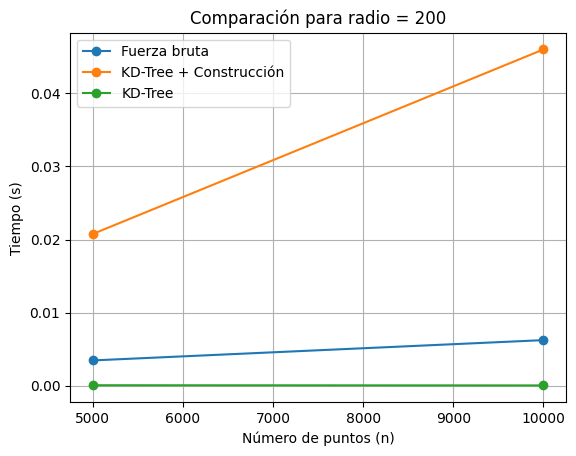

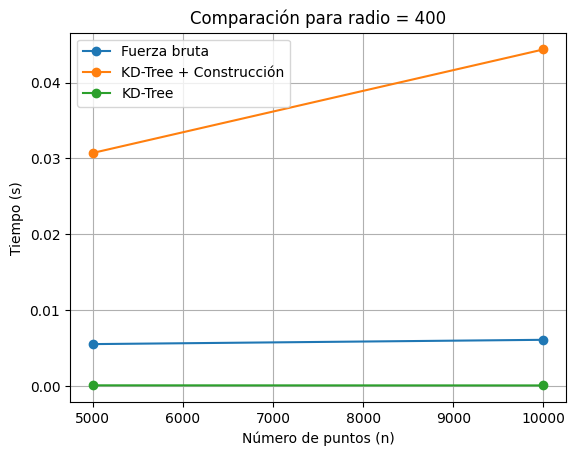

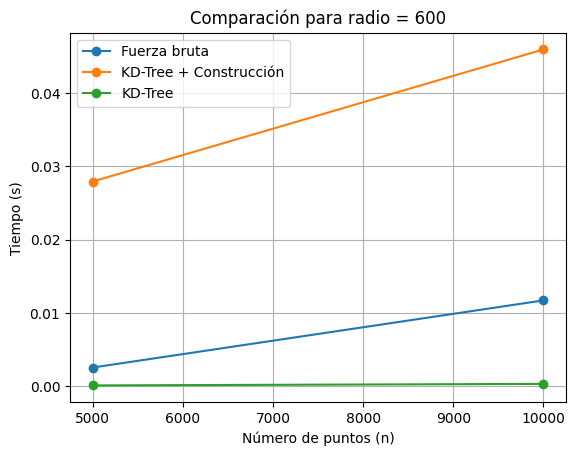

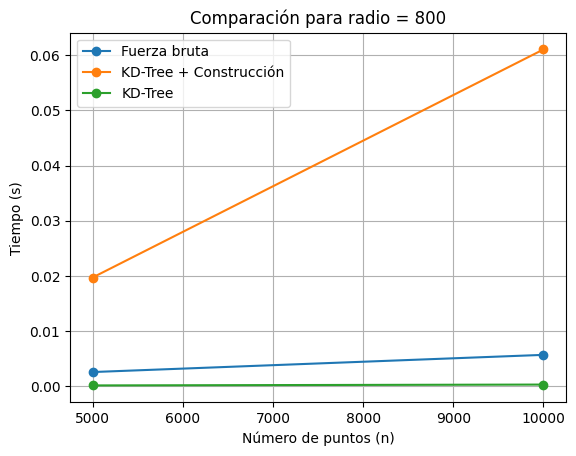

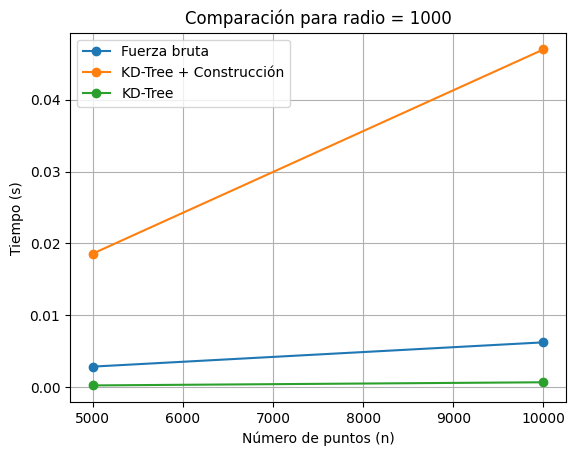

In [21]:
graficar_resultados(exp_radio)